In [1]:
%load_ext autoreload
%autoreload 2
import sisl
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

from mytools.scalingv2 import rsse_mapping
from mytools.construct import make_edge, all_armchair
from mytools.plots import thesis_fig

In [2]:
BOND = 1.42
phi = np.pi/3
B = BOND*np.cos(phi/2)

N0 = 4
N_small = 6
N_big = 11
NC = 1

R = (0.1, BOND+1e-2)
T = (0.0, -2.7)

ETA = 1e-3
NUMK = 400

## helper functions

In [3]:
# will sub the hamiltonian to order the electrode indices first
def resub_ham(rsse):
    Ham_rs, elec_idx = rsse.real_space_coupling(ret_indices=True)
    Ham_NN = rsse.real_space_parent()
    all_idx = np.arange(Ham_NN.na)
    device_idx = np.delete(all_idx, elec_idx)
    sub_idx = np.concat([elec_idx, device_idx])
    Ham_NN_re = Ham_NN.sub(sub_idx)
    
    out = {
        "H_elec": Ham_rs,
        "elec_idx": elec_idx,
        "sub_idx": sub_idx,
        
    }
    return Ham_NN_re, out

In [4]:
graphene6 = all_armchair(BOND)

Ham0 = sisl.Hamiltonian(graphene6)
Ham0.construct([R, T])

In [5]:
rsse_small = sisl.RealSpaceSE(Ham0, 0, 1, (N_small, N_small, 1))
rsse_small.setup(eta=ETA, 
            bz=sisl.MonkhorstPack(Ham0, [1, NUMK, 1]))

rsse_big = sisl.RealSpaceSE(Ham0, 0, 1, (N_big, N_big, 1))
rsse_big.setup(eta=ETA, 
            bz=sisl.MonkhorstPack(Ham0, [1, NUMK, 1]))


In [6]:
Ham_elec_small, elec_idx_small = rsse_small.real_space_coupling(ret_indices=True)
Ham_elec_big, elec_idx_big = rsse_big.real_space_coupling(ret_indices=True)

In [7]:
Ham_NN_small = rsse_small.real_space_parent()
Ham_NN_big = rsse_big.real_space_parent()

In [8]:
all_idx_small = np.arange(Ham_NN_small.na)
all_idx_big = np.arange(Ham_NN_big.na)

In [9]:
device_idx_small = np.delete(all_idx_small, elec_idx_small)
device_idx_big = np.delete(all_idx_big, elec_idx_big)

In [10]:
sub_idx_small = np.concat([elec_idx_small, device_idx_small])
sub_idx_big = np.concat([elec_idx_big, device_idx_big])

In [11]:
Ham_reord_small = Ham_NN_small.sub(sub_idx_small)
Ham_reord_big = Ham_NN_big.sub(sub_idx_big)

In [ ]:
# Ham_reord_small, resub_dict_small = resub_ham(rsse_small)
# Ham_reord_big, resub_dict_big = resub_ham(rsse_big)

In [ ]:
# elec_idx_small = resub_dict_small['elec_idx']
# elec_idx_big = resub_dict_big['elec_idx']

In [ ]:
# H_elec_small = resub_dict_small['H_elec']
# H_elec_big = resub_dict_big["H_elec"]

In [ ]:
# sub_idx_small = resub_dict_small['sub_idx']
# sub_idx_big = resub_dict_big['sub_idx']

In [12]:
print(rsse_small._unfold.prod()*rsse_small.parent.na, Ham_reord_small.na)
print(rsse_big._unfold.prod()*rsse_big.parent.na, Ham_reord_big.na)

216 216
726 726


In [13]:
geom_edge_small = make_edge(Ham0.geometry, N_small, N_small)
geom_edge_big = make_edge(Ham0.geometry, N_big, N_big)

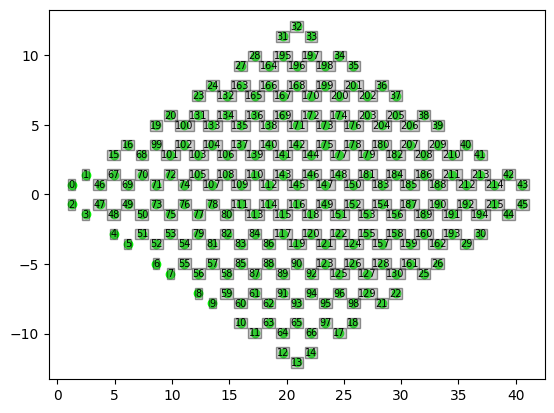

In [14]:
fig, ax = plt.subplots()
ax.scatter(*Ham_reord_small.xyz.T[:2], color="lime")
for i, (x,y,_) in enumerate(Ham_reord_small.xyz):
    ax.text(x,y,i,fontsize=7,ha="center",va="center",
            bbox=dict(facecolor="grey", alpha=0.4, pad=0.2)
    )

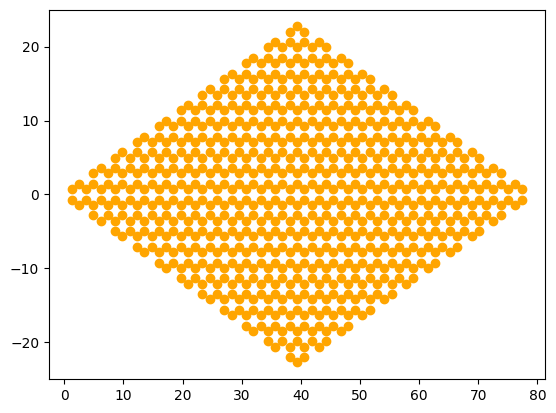

In [43]:
fig, ax = plt.subplots()
ax.scatter(*Ham_reord_big.xyz.T[:2], color="orange")
# for i, (x,y,_) in enumerate(Ham_reord_big.xyz):
#     ax.text(x,y,i,fontsize=7,ha="center",va="center",
#             bbox=dict(facecolor="grey", alpha=0.4, pad=0.2)
#     )

# RSSE calculations

In [15]:
emax = 0.5
emin = -emax
h = 0.1
energies = np.arange(emin, emax, h)

In [ ]:
# initialize all arrays for RSSE calculations
rsse_collection_small = np.zeros(shape=(energies.shape + 2*(Ham_reord_small.na,)), dtype=complex)
rsse_collection_big = np.zeros(shape=(energies.shape + 2*(Ham_reord_big.na,)), dtype=complex)

# initialize array identical to 'big' to store extrapolation RSSE data
rsse_collection_extrapolations = rsse_collection_big.copy()

In [ ]:
print(rsse_collection_big.shape, rsse_collection_small.shape, rsse_collection_extrapolations.shape)

In [ ]:
for i, E in enumerate(tqdm(energies, desc="geometry 2")):
    z = E + ETA*1j
    _rsse = rsse_big.self_energy(z)
    rsse_collection_big[i] += _rsse[np.ix_(sub_idx_big, sub_idx_big)]
    del _rsse

np.savez(f"./rsse/rsse_from_extrapolation_N{N_big}", data=rsse_collection_big)
del rsse_collection_big


In [16]:
big_to_small_idx = rsse_mapping(Ham_elec_small, Ham_elec_big, geom_edge_small, geom_edge_big, N_small, N_big, Ham0.na, NC=NC)
big_to_small_idx.values()

dict_values([0, 1, 2, 3, 4, 5, 6, 7, 6, 7, 6, 7, 6, 7, 8, 9, 8, 9, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 19, 20, 21, 22, 19, 20, 21, 22, 19, 20, 21, 22, 23, 24, 25, 26, 23, 24, 25, 26, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 36, 37, 36, 37, 36, 37, 38, 39, 38, 39, 38, 39, 40, 41, 42, 43, 44, 45])

In [ ]:
for i, E in enumerate(tqdm(energies, desc="geometry 2")):
    z = E + ETA*1j
    _rsse = rsse_small.self_energy(z)
    rsse_collection_small[i] += _rsse[np.ix_(sub_idx_small, sub_idx_small)]
    rsse_collection_extrapolations[i, :len(elec_idx_big), :len(elec_idx_big)] += _rsse[np.ix_(sub_idx_small[list(big_to_small_idx.values())], sub_idx_small[list(big_to_small_idx.values())])]
    del _rsse

np.savez(f"./rsse/rsse_from_extrapolation_N{N_small}", data=rsse_collection_small)
np.savez(f"./rsse/rsse_from_extrapolation_{N_small}-to-{N_big}", data=rsse_collection_extrapolations)
del rsse_collection_small

In [17]:
rsse_collection_big = np.load(f"rsse/rsse_from_extrapolation_N{N_big}.npz")["data"]
rsse_collection_small = np.load(f"rsse/rsse_from_extrapolation_N{N_small}.npz")["data"]
rsse_collection_extrapolations = np.load(f"rsse/rsse_from_extrapolation_{N_small}-to-{N_big}.npz")["data"]


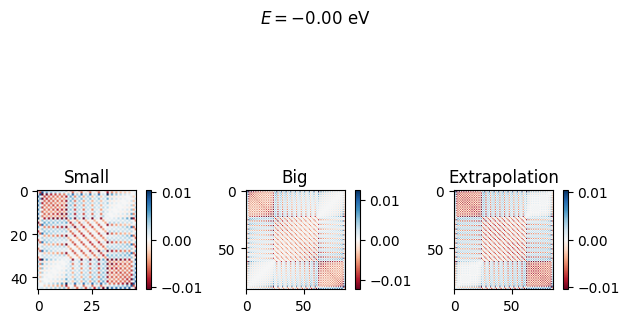

In [18]:
fig, ax = plt.subplots(1,3)

eidx = len(energies)//2
test = rsse_collection_small[eidx].imag
cmap = "RdBu"
vmax = np.abs(test.max())
vmin = -vmax
im = ax[0].imshow(test[:len(elec_idx_small), :len(elec_idx_small)], cmap=cmap, vmin=vmin, vmax=vmax)
ax[0].set_title("Small")
divider = make_axes_locatable(ax[0])
cax = divider.append_axes("right", size="5%", pad=0.1)

fig.colorbar(im, cax)
del im

test = rsse_collection_big[eidx].imag
vmax = np.abs(test.max())
vmin = -vmax
im = ax[1].imshow(test[:len(elec_idx_big), :len(elec_idx_big)],
                  cmap=cmap, vmin=vmin, vmax=vmax
                  )
ax[1].set_title("Big")

divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im, cax)


test = rsse_collection_extrapolations[eidx].imag
vmax = np.abs(test.max())
vmin = -vmax
im = ax[2].imshow(test[:len(elec_idx_big), :len(elec_idx_big)],
                  cmap=cmap, vmin=vmin, vmax=vmax
                  )
ax[2].set_title("Extrapolation")

divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im, cax)

fig.tight_layout()
fig.suptitle(f"$E = {energies[eidx]:.2f}$ eV")
fig.set_constrained_layout_pads()


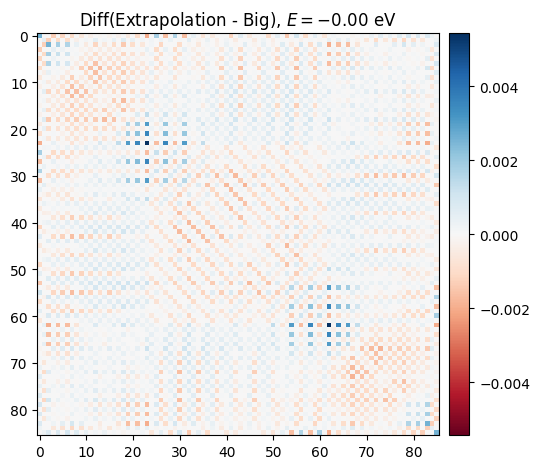

In [24]:
test = rsse_collection_extrapolations[eidx].imag - rsse_collection_big[eidx].imag
fig, ax = plt.subplots()

vmax = np.abs(test.max())
vmin = -vmax
im = ax.imshow(test[:len(elec_idx_big), :len(elec_idx_big)],
                  cmap=cmap, vmin=vmin, vmax=vmax
                  )
ax.set_title(f"Diff(Extrapolation - Big), $E = {energies[eidx]:.2f}$ eV")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im, cax)

fig.tight_layout()
# fig.suptitle(f"$E = {energies[eidx]:.2f}$ eV")
fig.set_constrained_layout_pads()

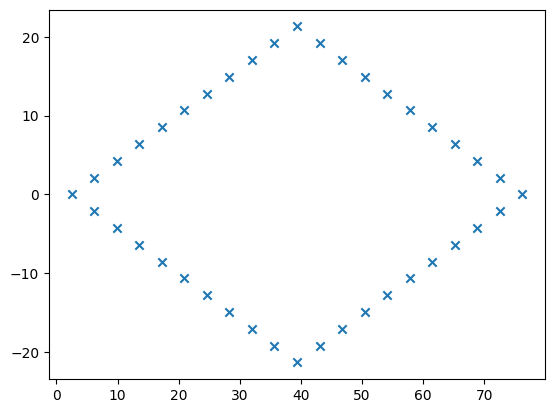

In [51]:
from mytools.scalingv2 import get_centers

centroids = get_centers(geom_edge_big, Ham0.na)


fig, ax = plt.subplots()
ax.scatter(*centroids.T[:2], marker="x")
# ax.scatter(*geom_edge_big.xyz.T[:2])

726


(np.float64(0.010428268575396131), np.float64(0.010428268575396131))

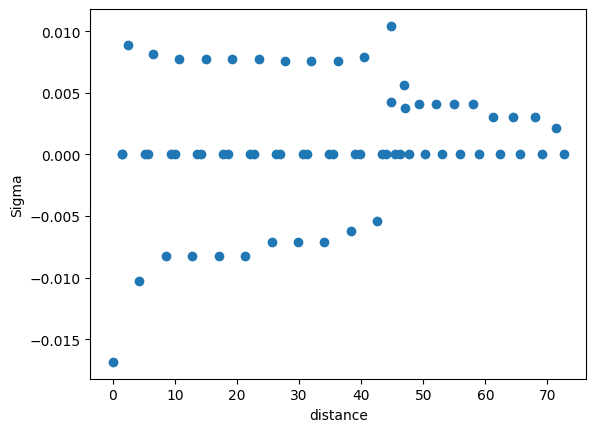

In [45]:

def dist(coords):
    return np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1)
print(Ham_reord_big.na)


plt.scatter(dist(Ham_reord_big.xyz).flatten()[:6*N_big], rsse_collection_extrapolations[eidx].imag.flatten()[:6*N_big])

plt.xlabel("distance")
plt.ylabel("Sigma")
rsse_collection_extrapolations[eidx].imag.max(), rsse_collection_small[eidx].imag.max()

In [ ]:
rsse_collection_extrapolations.shape

(10, 726, 726)